<a href="https://colab.research.google.com/github/Sarvamm/ds-ml-projects/blob/main/Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
import pandas as pd
import numpy as np
import random as rd
from pathlib import Path

#Data Viz
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#WordCloud
# from wordcloud import WordCloud

#Stats
import scipy.stats as stats

#Machine Learning
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline

# from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
# from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
# from sklearn.svm import SVC

# import xgboost as xgb
# import lightgbm as lgb
# import catboost as cb

# from sklearn.metrics import (
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     roc_auc_score,
#     mean_absolute_error,
#     mean_squared_error,
#     confusion_matrix,
#     classification_report
# )

################################################################################

# Configs

# Set the global theme to high-res and clean
#Themes: darkgrid, whitegrid, dark, white, ticks
#Palettes: deep, muted, bright, colorblind
#Context: paper, talk, poster, notebook
sns.set_theme(
    context= "paper",
    style="darkgrid",
    palette="muted")

plt.rcParams['figure.figsize'] = (6,3)   # Default plot size
plt.rcParams['figure.dpi'] = 150

RANDOM_STATE = 278453

In [ ]:
#Paths

path = Path.cwd() / "data" / "data.csv"

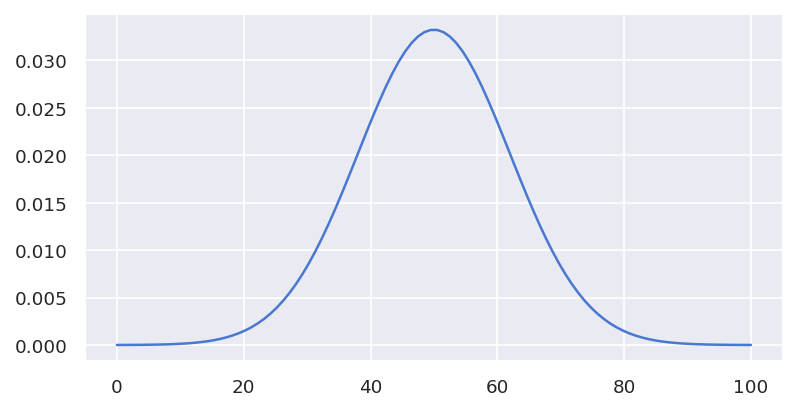

In [77]:
x = np.linspace(0, 100, 100)
y_norm = stats.norm.pdf(x, loc= 50, scale = 12)

sns.lineplot(x=x, y=y_norm, );

In [107]:
from sklearn.datasets import make_classification

# Create a synthetic classification dataset
X, y = make_classification(n_samples=10_000, n_features=5, n_classes=2, )

# Convert to DataFrame to see it clearly
df = pd.DataFrame(X, columns=[f'Feature_{i}' for i in range(5)])
df['target'] = y

df

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,target
0,1.418620,0.922207,1.452256,0.530177,0.655182,1
1,2.190968,1.705325,2.224165,-0.850632,0.726993,1
2,-1.408269,-0.685534,-1.457003,0.505869,-0.883504,0
3,-3.453790,-1.893673,-3.559138,-0.113923,-1.951487,0
4,0.760644,0.667630,0.767126,0.465851,0.175766,1
...,...,...,...,...,...,...
9995,3.618263,1.999272,3.727599,-0.593363,2.028787,1
9996,-5.295477,-2.173422,-5.505712,0.575660,-3.732142,0
9997,1.008481,0.673764,1.031180,1.085913,0.447335,1
9998,0.153063,0.087407,0.157499,0.977280,0.082952,1


In [86]:
df.describe()

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Target
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,-0.070833,0.093086,-0.020675,0.021787,-0.025177,0.500000
std,1.347819,1.121023,0.779766,1.216777,1.003382,0.502519
min,-2.867175,-3.246603,-1.946254,-2.612382,-2.515003,0.000000
25%,-1.209863,-0.553734,-0.727238,-1.056137,-0.911850,0.000000
50%,0.084455,0.107034,-0.124214,0.312030,-0.167604,0.500000
75%,0.965254,0.792877,0.753138,1.009407,0.972314,1.000000
max,2.963381,2.880746,1.528036,3.074478,2.002683,1.000000


In [109]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('target', axis='columns' ), df.target,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y  # Essential for classification!
)

In [110]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((8000, 5), (8000,), (2000, 5), (2000,))

In [115]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

model.fit( X_train, y_train )

LogisticRegression(max_iter=1000)

In [116]:
y_ = model.predict( X_test )

In [117]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix


In [118]:
print(classification_report( y_test, y_ ))

              precision    recall  f1-score   support

           0       0.89      0.90      0.90      1000
           1       0.90      0.88      0.89      1000

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000



---

In [124]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.svm import SVC

# Define the models you want to test
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE),
    "SVM": SVC(probability=True)

}

In [125]:
results = []

for name, model in models.items():
    # 1. Fit the model
    model.fit(X_train, y_train)

    # 2. Make predictions
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1] # For AUC

    # 3. Calculate metrics
    accuracy = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)

    # 4. Save results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "AUC-ROC": auc
    })

# Convert results list to a DataFrame for easy comparison
comparison_df = pd.DataFrame(results).sort_values(by="AUC-ROC", ascending=False)

In [126]:
comparison_df

,Model,Accuracy,AUC-ROC
0,Logistic Regression,0.8940,0.954778
3,SVM,0.8945,0.951606
2,XGBoost,0.8900,0.951505
1,Random Forest,0.8925,0.950627


---

In [127]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

mlp_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=500,
        activation='relu',
        solver='adam',
        random_state=RANDOM_STATE
    ))
])

# 2. Fit and Predict
mlp_pipe.fit(X_train, y_train)
y_pred = mlp_pipe.predict(X_test)

In [129]:
print(classification_report(y_pred= y_pred, y_true= y_test))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90      1000
           1       0.92      0.88      0.89      1000

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000

